# **Tugas Besar II4012 AI untuk Bisnis:**  AI Player Scouting

---  

![alt text](image.png)


Praktikum ini disusun oleh:
|Nama Lengkap|NIM
|:-|:-:|
|Ananda Fajrul Zidan|18223067|
|||
|||
|||


## **Inisiasi**  
---  

### Import Library
- **pandas**: Untuk manipulasi dan analisis data dalam format tabel (DataFrame)
- **matplotlib.pyplot**: Library untuk membuat visualisasi/grafik
- **glob**: Untuk mencari file dengan pola tertentu di direktori (contoh: `ea-sports-fc-*.csv`)
- **seaborn**: Library visualisasi yang dibangun di atas matplotlib untuk grafik yang lebih menarik

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import seaborn as sns
import pickle 

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

### Membaca dan Menggabungkan Data CSV
- **glob.glob()**: Mencari semua file yang cocok dengan pola `ea-sports-fc-*.csv` (file dengan awalan "ea-sports-fc-" dan ekstensi .csv)
- **Loop for**: Membaca setiap file CSV satu per satu dan menyimpannya ke dalam list `df_list`
- **pd.concat()**: Menggabungkan semua DataFrame dalam list menjadi satu DataFrame besar (`df_master`)
- **ignore_index=True**: Mereset index agar tidak ada duplikasi nomor baris setelah penggabungan
- **to_csv()**: Menyimpan data gabungan ke file `ea_fc_26_master_dataset.csv` untuk backup

In [2]:
file_list = glob.glob('ea-sports-fc-*.csv')
df_list = []

for file in file_list:
    df_temp = pd.read_csv(file)
    df_list.append(df_temp)

df_master = pd.concat(df_list, ignore_index=True)
print(f"Total pemain yang terkumpul: {len(df_master)}")
df_master.to_csv('ea_fc_26_master_dataset.csv', index=False)

Total pemain yang terkumpul: 1000


### Menampilkan Nama Kolom
- **list(df_master.columns.values)**: Mengubah nama-nama kolom dari DataFrame menjadi list untuk memudahkan melihat semua fitur/variabel yang tersedia dalam dataset

In [3]:
list(df_master.columns.values)

['id',
 'rank',
 'overallRating',
 'firstName',
 'lastName',
 'commonName',
 'birthdate',
 'height',
 'skillMoves',
 'weakFootAbility',
 'preferredFoot',
 'leagueName',
 'weight',
 'avatarUrl',
 'shieldUrl',
 'alternatePositions/0/id',
 'alternatePositions/0/label',
 'alternatePositions/0/shortLabel',
 'playerAbilities/0/id',
 'playerAbilities/0/label',
 'playerAbilities/0/description',
 'playerAbilities/0/imageUrl',
 'playerAbilities/0/type/id',
 'playerAbilities/0/type/label',
 'playerAbilities/1/id',
 'playerAbilities/1/label',
 'playerAbilities/1/description',
 'playerAbilities/1/imageUrl',
 'playerAbilities/1/type/id',
 'playerAbilities/1/type/label',
 'playerAbilities/2/id',
 'playerAbilities/2/label',
 'playerAbilities/2/description',
 'playerAbilities/2/imageUrl',
 'playerAbilities/2/type/id',
 'playerAbilities/2/type/label',
 'playerAbilities/3/id',
 'playerAbilities/3/label',
 'playerAbilities/3/description',
 'playerAbilities/3/imageUrl',
 'playerAbilities/3/type/id',
 'play

## **Pre-Processing**  
---  

### Matriks Korelasi
- **df_master.corr()**: Menghitung korelasi (hubungan) antar kolom numerik dalam dataset
- **numeric_only=True**: Hanya menghitung korelasi untuk kolom bertipe angka, mengabaikan kolom teks
- Hasil menunjukkan nilai korelasi dari -1 (negatif sempurna) hingga +1 (positif sempurna), dengan 0 berarti tidak ada hubungan

In [6]:
df_master.corr(numeric_only=True)

,id,rank,overallRating,height,skillMoves,weakFootAbility,preferredFoot,weight,alternatePositions/0/id,gender/id,...,stats/standingTackle/value,stats/standingTackle/diff,stats/vision/value,stats/vision/diff,stats/volleys/value,stats/volleys/diff,alternatePositions/1/id,alternatePositions/0,alternatePositions/2/id,team
id,1.000000,0.116389,-0.108260,-0.065692,0.086903,0.011180,0.054906,-0.127271,-0.025469,NaN,...,0.133443,NaN,0.029046,NaN,0.005377,NaN,0.016383,NaN,0.171611,NaN
rank,0.116389,1.000000,-0.935568,-0.092783,-0.086075,-0.159868,-0.012002,-0.073218,-0.071943,NaN,...,-0.002954,NaN,-0.216857,NaN,-0.113656,NaN,-0.058690,NaN,0.070810,NaN
overallRating,-0.108260,-0.935568,1.000000,0.094140,0.089980,0.160242,0.006934,0.076637,0.101183,NaN,...,-0.015688,NaN,0.203365,NaN,0.109233,NaN,0.069643,NaN,-0.064661,NaN
height,-0.065692,-0.092783,0.094140,1.000000,-0.548614,-0.081443,-0.111512,0.780945,-0.175722,NaN,...,-0.166441,NaN,-0.529605,NaN,-0.452226,NaN,-0.188538,NaN,0.039791,NaN
skillMoves,0.086903,-0.086075,0.089980,-0.548614,1.000000,0.236431,0.145632,-0.515674,0.424343,NaN,...,0.174223,NaN,0.707428,NaN,0.785169,NaN,0.311973,NaN,0.051631,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
stats/volleys/diff,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alternatePositions/1/id,0.016383,-0.058690,0.069643,-0.188538,0.311973,-0.035935,0.084198,-0.150910,0.152743,NaN,...,-0.430276,NaN,0.181976,NaN,0.313448,NaN,1.000000,NaN,-0.030278,NaN
alternatePositions/0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alternatePositions/2/id,0.171611,0.070810,-0.064661,0.039791,0.051631,0.130537,-0.143762,-0.087872,-0.013518,NaN,...,-0.100125,NaN,0.051170,NaN,0.072249,NaN,-0.030278,NaN,1.000000,NaN


<Axes: >

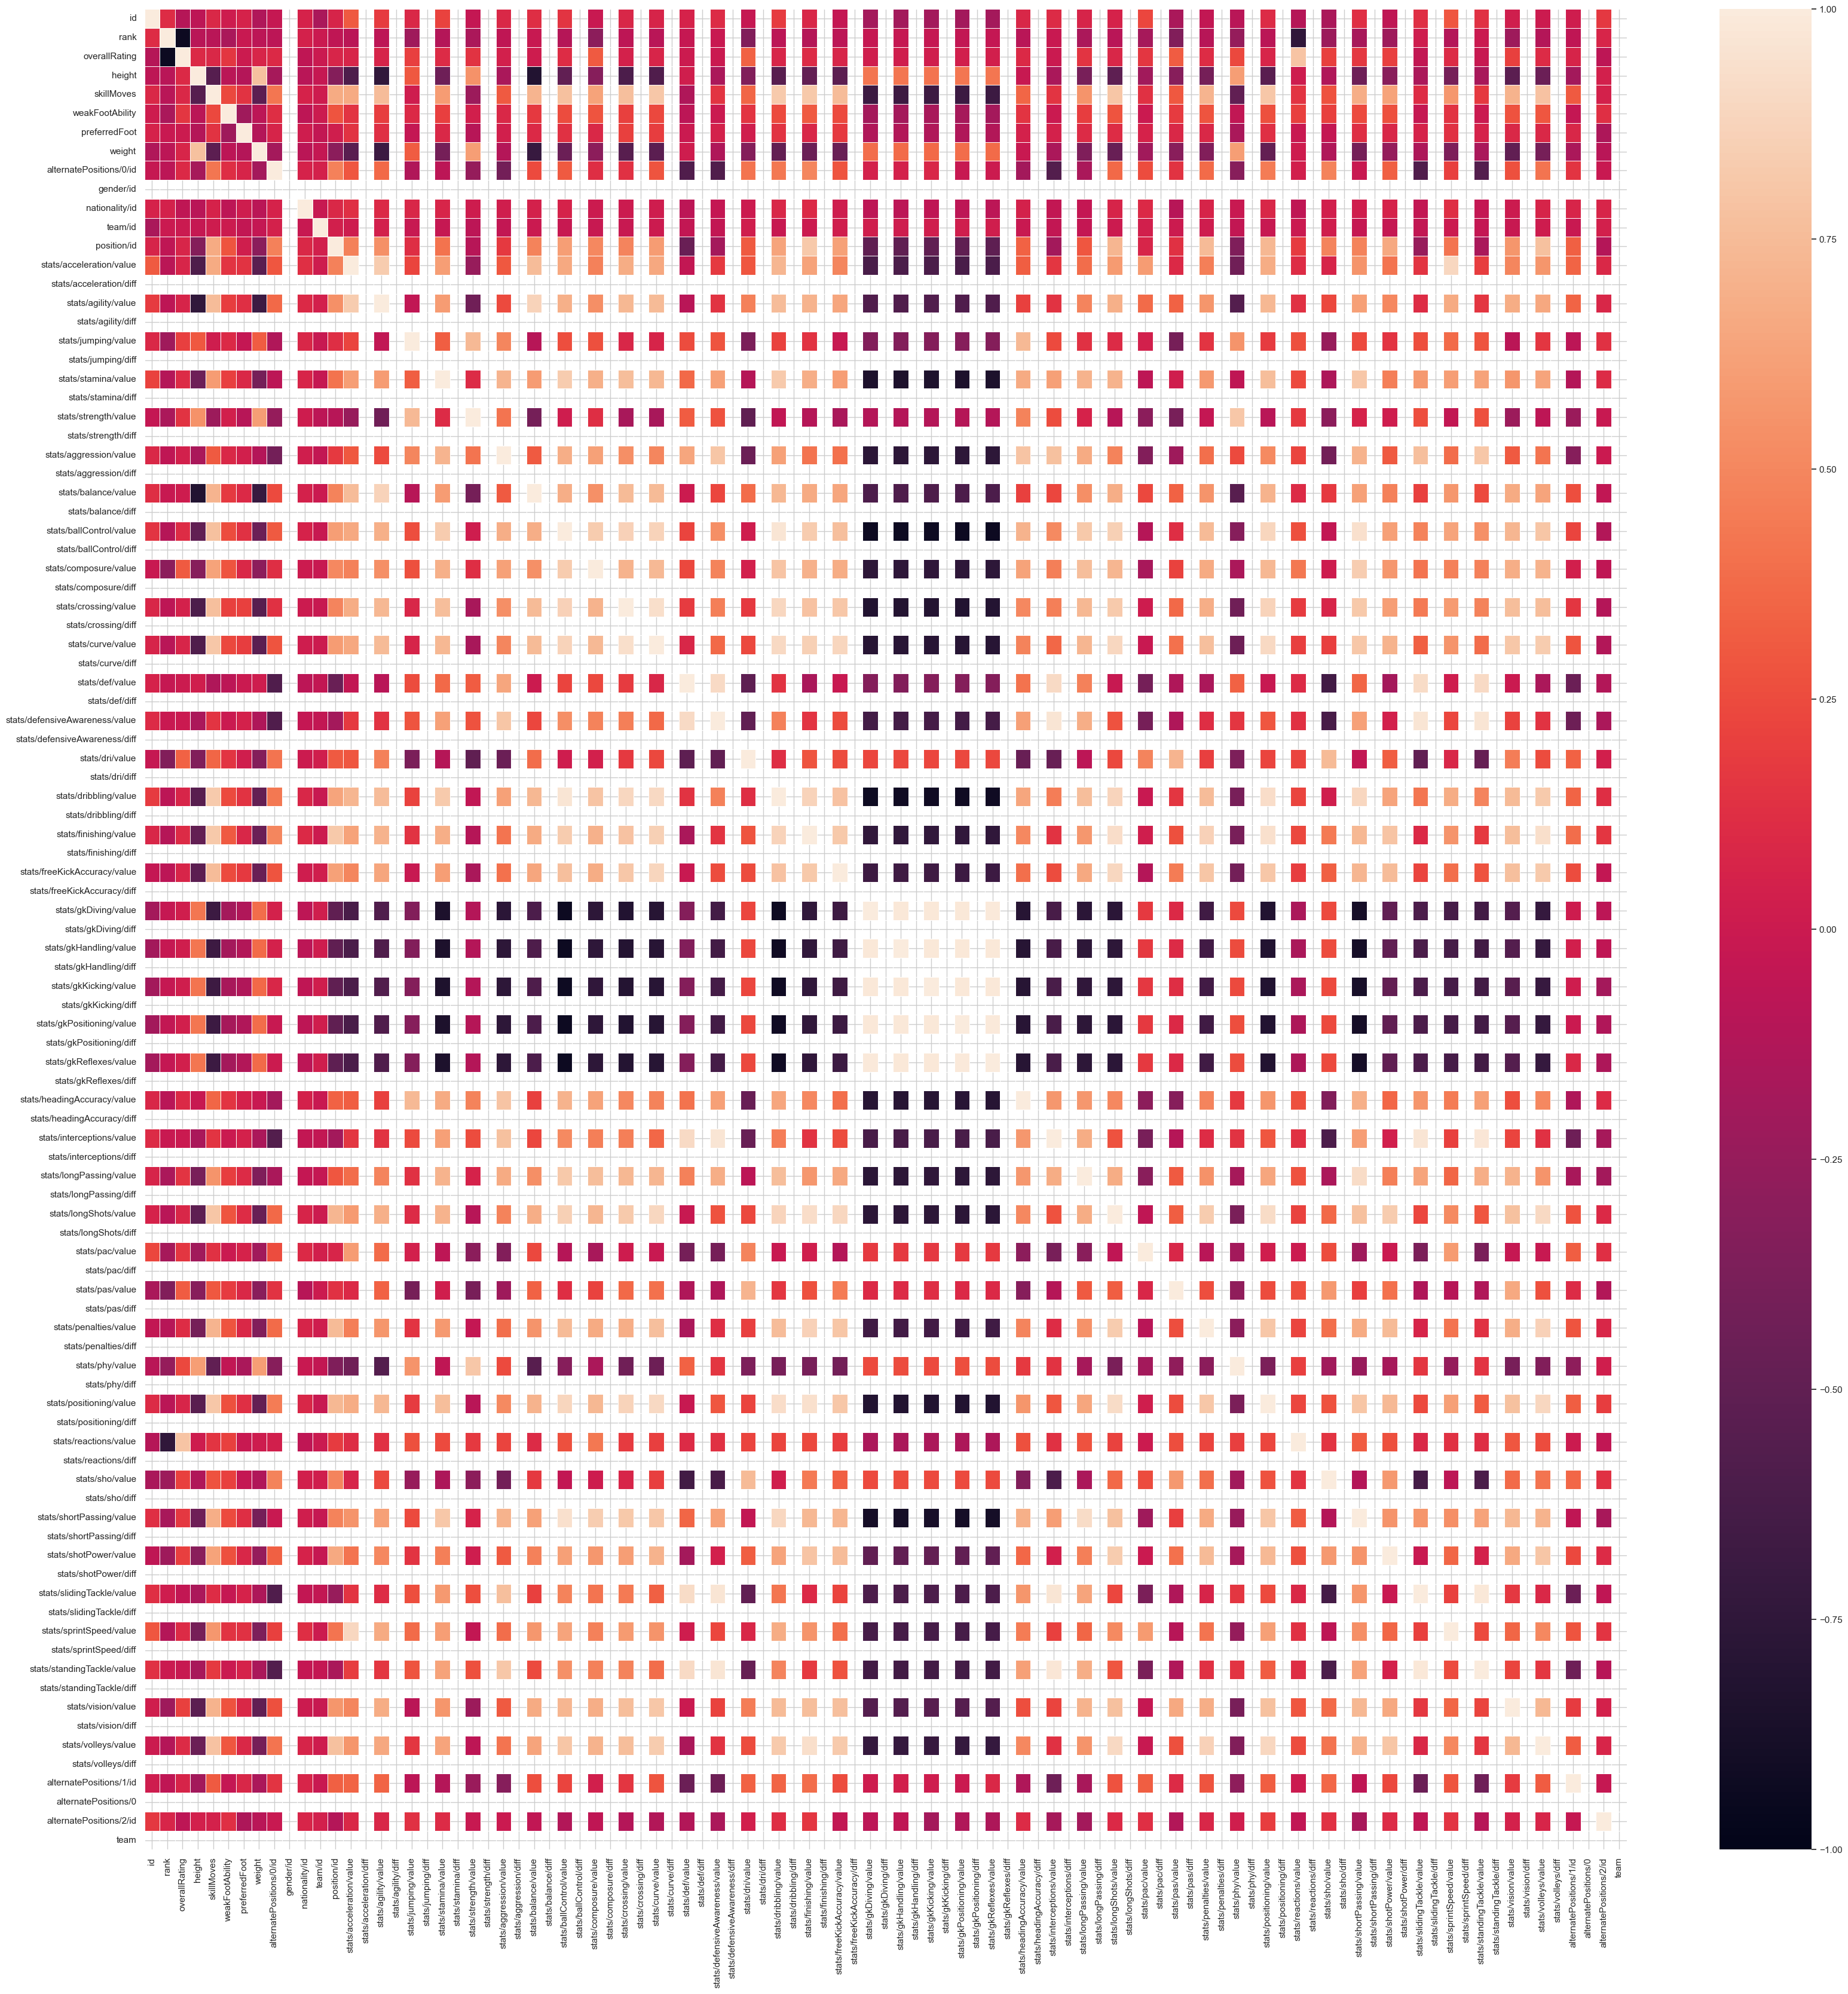

In [7]:
plt.figure(figsize=(40, 40)) 

sns.heatmap(
    df_master.corr(numeric_only=True), 
    vmin=-1, vmax=1,
    linewidths=0.5
)

### Inisialisasi Data Cleaning
- **df_clean = df_master.copy()**: Membuat salinan dari `df_master` untuk data cleaning tanpa mengubah data asli
- **list(df_clean.columns.values)**: Menampilkan semua nama kolom yang ada
- **len()**: Menghitung jumlah total kolom yang ada

In [8]:
df_clean = df_master.copy()
print(list(df_clean.columns.values))
len(list(df_clean.columns.values))

['id', 'rank', 'overallRating', 'firstName', 'lastName', 'commonName', 'birthdate', 'height', 'skillMoves', 'weakFootAbility', 'preferredFoot', 'leagueName', 'weight', 'avatarUrl', 'shieldUrl', 'alternatePositions/0/id', 'alternatePositions/0/label', 'alternatePositions/0/shortLabel', 'playerAbilities/0/id', 'playerAbilities/0/label', 'playerAbilities/0/description', 'playerAbilities/0/imageUrl', 'playerAbilities/0/type/id', 'playerAbilities/0/type/label', 'playerAbilities/1/id', 'playerAbilities/1/label', 'playerAbilities/1/description', 'playerAbilities/1/imageUrl', 'playerAbilities/1/type/id', 'playerAbilities/1/type/label', 'playerAbilities/2/id', 'playerAbilities/2/label', 'playerAbilities/2/description', 'playerAbilities/2/imageUrl', 'playerAbilities/2/type/id', 'playerAbilities/2/type/label', 'playerAbilities/3/id', 'playerAbilities/3/label', 'playerAbilities/3/description', 'playerAbilities/3/imageUrl', 'playerAbilities/3/type/id', 'playerAbilities/3/type/label', 'playerAbiliti

162

### Menghapus Kolom yang Mengandung 'url'
- **str.contains('url', case=False)**: Mencari semua kolom yang nama-nya mengandung kata "url" (tidak memperhatikan huruf besar/kecil)
- **drop(columns=...)**: Menghapus kolom-kolom tersebut karena URL tidak berguna untuk model machine learning
- Kolom URL biasanya hanya link ke gambar/profil dan tidak memberikan informasi prediktif

In [9]:
df_clean = df_clean.drop(columns=df_clean.columns[df_clean.columns.str.contains('url', case=False)])
print(list(df_clean.columns.values))
len(list(df_clean.columns.values))

['id', 'rank', 'overallRating', 'firstName', 'lastName', 'commonName', 'birthdate', 'height', 'skillMoves', 'weakFootAbility', 'preferredFoot', 'leagueName', 'weight', 'alternatePositions/0/id', 'alternatePositions/0/label', 'alternatePositions/0/shortLabel', 'playerAbilities/0/id', 'playerAbilities/0/label', 'playerAbilities/0/description', 'playerAbilities/0/type/id', 'playerAbilities/0/type/label', 'playerAbilities/1/id', 'playerAbilities/1/label', 'playerAbilities/1/description', 'playerAbilities/1/type/id', 'playerAbilities/1/type/label', 'playerAbilities/2/id', 'playerAbilities/2/label', 'playerAbilities/2/description', 'playerAbilities/2/type/id', 'playerAbilities/2/type/label', 'playerAbilities/3/id', 'playerAbilities/3/label', 'playerAbilities/3/description', 'playerAbilities/3/type/id', 'playerAbilities/3/type/label', 'playerAbilities/4/id', 'playerAbilities/4/label', 'playerAbilities/4/description', 'playerAbilities/4/type/id', 'playerAbilities/4/type/label', 'playerAbilitie

151

### Menghapus Kolom yang Mengandung 'id'
- **str.contains('id', case=False)**: Mencari semua kolom yang nama-nya mengandung kata "id"
- **drop(columns=...)**: Menghapus kolom ID karena setiap pemain memiliki ID unik yang tidak berguna untuk prediksi
- ID hanya digunakan untuk identifikasi unik, bukan untuk model pembelajaran

In [10]:
df_clean = df_clean.drop(columns=df_clean.columns[df_clean.columns.str.contains('id', case=False)])
print(list(df_clean.columns.values))
len(list(df_clean.columns.values))

['rank', 'overallRating', 'firstName', 'lastName', 'commonName', 'birthdate', 'height', 'skillMoves', 'weakFootAbility', 'preferredFoot', 'leagueName', 'weight', 'alternatePositions/0/label', 'alternatePositions/0/shortLabel', 'playerAbilities/0/label', 'playerAbilities/0/description', 'playerAbilities/0/type/label', 'playerAbilities/1/label', 'playerAbilities/1/description', 'playerAbilities/1/type/label', 'playerAbilities/2/label', 'playerAbilities/2/description', 'playerAbilities/2/type/label', 'playerAbilities/3/label', 'playerAbilities/3/description', 'playerAbilities/3/type/label', 'playerAbilities/4/label', 'playerAbilities/4/description', 'playerAbilities/4/type/label', 'playerAbilities/5/label', 'playerAbilities/5/description', 'playerAbilities/5/type/label', 'playerAbilities/6/label', 'playerAbilities/6/description', 'playerAbilities/6/type/label', 'gender/label', 'nationality/label', 'team/label', 'team/isPopular', 'position/shortLabel', 'position/label', 'position/positionT

126

### Menghapus Kolom yang Mengandung 'diff'
- **str.contains('diff', case=False)**: Mencari semua kolom yang nama-nya mengandung kata "diff"
- **drop(columns=...)**: Menghapus kolom "diff" (difference/perbedaan) karena mungkin redundan atau tidak relevan untuk prediksi
- Kolom ini biasanya menunjukkan perbedaan nilai (misalnya rating sebelum dan sesudah), yang dapat diganti dengan nilai absolut

In [11]:
df_clean = df_clean.drop(columns=df_clean.columns[df_clean.columns.str.contains('diff', case=False)])
print(list(df_clean.columns.values))
len(list(df_clean.columns.values))

['rank', 'overallRating', 'firstName', 'lastName', 'commonName', 'birthdate', 'height', 'skillMoves', 'weakFootAbility', 'preferredFoot', 'leagueName', 'weight', 'alternatePositions/0/label', 'alternatePositions/0/shortLabel', 'playerAbilities/0/label', 'playerAbilities/0/description', 'playerAbilities/0/type/label', 'playerAbilities/1/label', 'playerAbilities/1/description', 'playerAbilities/1/type/label', 'playerAbilities/2/label', 'playerAbilities/2/description', 'playerAbilities/2/type/label', 'playerAbilities/3/label', 'playerAbilities/3/description', 'playerAbilities/3/type/label', 'playerAbilities/4/label', 'playerAbilities/4/description', 'playerAbilities/4/type/label', 'playerAbilities/5/label', 'playerAbilities/5/description', 'playerAbilities/5/type/label', 'playerAbilities/6/label', 'playerAbilities/6/description', 'playerAbilities/6/type/label', 'gender/label', 'nationality/label', 'team/label', 'team/isPopular', 'position/shortLabel', 'position/label', 'position/positionT

87

### Menampilkan Kolom Numerik
- **select_dtypes(include=['number'])**: Memilih hanya kolom-kolom yang bertipe data numerik (int, float)
- Berguna untuk melihat berapa banyak fitur numerik yang tersedia setelah pembersihan

In [13]:
df_clean.select_dtypes(include=['number'])

,rank,overallRating,height,skillMoves,weakFootAbility,preferredFoot,weight,stats/acceleration/value,stats/agility/value,stats/jumping/value,...,stats/reactions/value,stats/sho/value,stats/shortPassing/value,stats/shotPower/value,stats/sprintSpeed/value,stats/standingTackle/value,stats/vision/value,stats/volleys/value,alternatePositions/0,team
0,1,91,175,4,3,2,72,88,86,79,...,94,88,88,83,89,43,89,83,NaN,NaN
1,3,91,182,5,4,1,75,97,93,90,...,91,90,87,91,97,34,83,87,NaN,NaN
2,5,90,178,5,5,2,67,93,94,84,...,91,88,89,91,89,49,84,79,NaN,NaN
3,6,90,190,3,4,1,82,65,66,83,...,93,80,93,92,65,87,84,71,NaN,NaN
4,8,90,193,2,3,1,92,66,54,89,...,90,60,80,81,78,91,70,45,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1306,77,186,3,3,1,73,61,68,72,...,73,70,80,73,67,78,76,65,NaN,NaN
996,1307,77,175,4,3,1,62,78,87,72,...,73,74,77,76,73,71,76,58,NaN,NaN
997,1308,77,179,4,3,2,73,87,84,70,...,74,67,72,70,92,66,70,58,NaN,NaN
998,1309,77,195,1,3,1,94,56,58,75,...,74,75,48,56,54,18,59,16,NaN,NaN


### Menampilkan Semua Nama Kolom
- **list(df_clean.columns.values)**: Menampilkan daftar lengkap semua kolom yang masih tersisa setelah penghapusan
- Digunakan untuk memeriksa kolom mana yang perlu dihapus selanjutnya

In [14]:
list(df_clean.columns.values)

['rank',
 'overallRating',
 'firstName',
 'lastName',
 'commonName',
 'birthdate',
 'height',
 'skillMoves',
 'weakFootAbility',
 'preferredFoot',
 'leagueName',
 'weight',
 'alternatePositions/0/label',
 'alternatePositions/0/shortLabel',
 'playerAbilities/0/label',
 'playerAbilities/0/description',
 'playerAbilities/0/type/label',
 'playerAbilities/1/label',
 'playerAbilities/1/description',
 'playerAbilities/1/type/label',
 'playerAbilities/2/label',
 'playerAbilities/2/description',
 'playerAbilities/2/type/label',
 'playerAbilities/3/label',
 'playerAbilities/3/description',
 'playerAbilities/3/type/label',
 'playerAbilities/4/label',
 'playerAbilities/4/description',
 'playerAbilities/4/type/label',
 'playerAbilities/5/label',
 'playerAbilities/5/description',
 'playerAbilities/5/type/label',
 'playerAbilities/6/label',
 'playerAbilities/6/description',
 'playerAbilities/6/type/label',
 'gender/label',
 'nationality/label',
 'team/label',
 'team/isPopular',
 'position/shortLabel'

### Filter Kolom yang Mengandung 'shortLabel'
- **filter(like='shortLabel')**: Memilih hanya kolom-kolom yang nama-nya mengandung kata "shortLabel"
- Ini untuk melihat kolom mana saja yang berisi label singkat yang mungkin redundan atau tidak berguna

In [15]:
df_clean.filter(like='shortLabel')

,alternatePositions/0/shortLabel,position/shortLabel,alternatePositions/1/shortLabel,alternatePositions/2/shortLabel
0,RW,RM,NaN,NaN
1,LW,ST,LM,NaN
2,RW,ST,CAM,NaN
3,CM,CDM,NaN,NaN
4,NaN,CB,NaN,NaN
...,...,...,...,...
995,CDM,CM,NaN,NaN
996,CM,CAM,LW,NaN
997,LB,LM,NaN,NaN
998,NaN,GK,NaN,NaN


### Menghapus Kolom yang Mengandung 'shortLabel'
- **str.contains('shortLabel', case=False)**: Mencari semua kolom yang mengandung kata "shortLabel"
- **drop(columns=...)**: Menghapus kolom-kolom tersebut karena label singkat tidak memberikan informasi prediktif
- Kolom label seringkali redundan dengan kolom kategori yang lebih jelas

In [16]:
df_clean = df_clean.drop(columns=df_clean.columns[df_clean.columns.str.contains('shortLabel', case=False)])
print(list(df_clean.columns.values))
len(list(df_clean.columns.values))

['rank', 'overallRating', 'firstName', 'lastName', 'commonName', 'birthdate', 'height', 'skillMoves', 'weakFootAbility', 'preferredFoot', 'leagueName', 'weight', 'alternatePositions/0/label', 'playerAbilities/0/label', 'playerAbilities/0/description', 'playerAbilities/0/type/label', 'playerAbilities/1/label', 'playerAbilities/1/description', 'playerAbilities/1/type/label', 'playerAbilities/2/label', 'playerAbilities/2/description', 'playerAbilities/2/type/label', 'playerAbilities/3/label', 'playerAbilities/3/description', 'playerAbilities/3/type/label', 'playerAbilities/4/label', 'playerAbilities/4/description', 'playerAbilities/4/type/label', 'playerAbilities/5/label', 'playerAbilities/5/description', 'playerAbilities/5/type/label', 'playerAbilities/6/label', 'playerAbilities/6/description', 'playerAbilities/6/type/label', 'gender/label', 'nationality/label', 'team/label', 'team/isPopular', 'position/label', 'position/positionType/name', 'stats/acceleration/value', 'stats/agility/valu

83

### Menghapus Kolom dengan Hanya 1 Nilai Unik
- **nunique() <= 1**: Menghitung berapa banyak nilai unik di setiap kolom
- Kolom dengan hanya 1 nilai unik tidak memberikan informasi variasi untuk model (semua pemain memiliki nilai yang sama)
- Loop ini otomatis menghapus semua kolom "konstan" yang tidak berguna

In [18]:
for col in df_clean.columns:
    if df_clean[col].nunique() <= 1:
        df_clean = df_clean.drop(columns=col)

In [19]:
print(list(df_clean.columns.values))
len(list(df_clean.columns.values))

['rank', 'overallRating', 'firstName', 'lastName', 'commonName', 'birthdate', 'height', 'skillMoves', 'weakFootAbility', 'preferredFoot', 'leagueName', 'weight', 'alternatePositions/0/label', 'playerAbilities/0/label', 'playerAbilities/0/description', 'playerAbilities/0/type/label', 'playerAbilities/1/label', 'playerAbilities/1/description', 'playerAbilities/1/type/label', 'playerAbilities/2/label', 'playerAbilities/2/description', 'playerAbilities/2/type/label', 'playerAbilities/3/label', 'playerAbilities/3/description', 'playerAbilities/3/type/label', 'playerAbilities/4/label', 'playerAbilities/4/description', 'playerAbilities/4/type/label', 'playerAbilities/5/label', 'playerAbilities/5/description', 'playerAbilities/5/type/label', 'playerAbilities/6/label', 'playerAbilities/6/description', 'playerAbilities/6/type/label', 'nationality/label', 'team/label', 'team/isPopular', 'position/label', 'position/positionType/name', 'stats/acceleration/value', 'stats/agility/value', 'stats/jumpi

80

### Menghapus Kolom yang Redundan Berdasarkan Analisis Korelasi
- **kolom_buang**: List kolom-kolom yang dipilih untuk dihapus berdasarkan analisis korelasi heatmap
- Kolom-kolom ini dipilih karena:
  - **pac, sho, pas, dri, def, phy**: Statistik umum yang mungkin redundan dengan sub-statistik spesifik
  - **sprintSpeed**: Mungkin tercakup dalam pace
  - **interceptions**: Statistik pertahanan khusus
  - **longShots**: Statistik penembakan khusus
  - **curve**: Statistik teknis yang spesifik
  - **rank, birthdate, overallRating**: Metadata yang tidak perlu untuk analisis komparatif
  - **team/isPopular**: Informasi tim yang tidak relevan untuk atribut pemain
- **drop(columns=...)**: Menghapus semua kolom dalam list tersebut

In [26]:
kolom_buang = ['stats/pac/value', 'stats/sho/value', 
               'stats/pas/value', 'stats/dri/value', 
               'stats/def/value', 'stats/phy/value',
               'stats/sprintSpeed/value', 'stats/interceptions/value',
               'stats/longShots/value', 'stats/curve/value',
               'rank', 'birthdate', 'overallRating', 'team/isPopular']

df_clean = df_clean.drop(columns=kolom_buang)
list(df_clean.columns.values)

['firstName',
 'lastName',
 'commonName',
 'height',
 'skillMoves',
 'weakFootAbility',
 'preferredFoot',
 'leagueName',
 'weight',
 'alternatePositions/0/label',
 'playerAbilities/0/label',
 'playerAbilities/0/description',
 'playerAbilities/0/type/label',
 'playerAbilities/1/label',
 'playerAbilities/1/description',
 'playerAbilities/1/type/label',
 'playerAbilities/2/label',
 'playerAbilities/2/description',
 'playerAbilities/2/type/label',
 'playerAbilities/3/label',
 'playerAbilities/3/description',
 'playerAbilities/3/type/label',
 'playerAbilities/4/label',
 'playerAbilities/4/description',
 'playerAbilities/4/type/label',
 'playerAbilities/5/label',
 'playerAbilities/5/description',
 'playerAbilities/5/type/label',
 'playerAbilities/6/label',
 'playerAbilities/6/description',
 'playerAbilities/6/type/label',
 'nationality/label',
 'team/label',
 'position/label',
 'position/positionType/name',
 'stats/acceleration/value',
 'stats/agility/value',
 'stats/jumping/value',
 'stats/

In [27]:
kamus_nama = {
    'position/label': 'position_name',
    'team/label': 'team_name',
    'nationality/label': 'nationality'
}

df_clean = df_clean.rename(columns=kamus_nama)
df_clean.columns = df_clean.columns.str.replace('stats/', '')
df_clean.columns = df_clean.columns.str.replace('/value', '')
df_clean.columns = df_clean.columns.str.replace('/', '_')

print(list(df_clean.columns.values))

['firstName', 'lastName', 'commonName', 'height', 'skillMoves', 'weakFootAbility', 'preferredFoot', 'leagueName', 'weight', 'alternatePositions_0_label', 'playerAbilities_0_label', 'playerAbilities_0_description', 'playerAbilities_0_type_label', 'playerAbilities_1_label', 'playerAbilities_1_description', 'playerAbilities_1_type_label', 'playerAbilities_2_label', 'playerAbilities_2_description', 'playerAbilities_2_type_label', 'playerAbilities_3_label', 'playerAbilities_3_description', 'playerAbilities_3_type_label', 'playerAbilities_4_label', 'playerAbilities_4_description', 'playerAbilities_4_type_label', 'playerAbilities_5_label', 'playerAbilities_5_description', 'playerAbilities_5_type_label', 'playerAbilities_6_label', 'playerAbilities_6_description', 'playerAbilities_6_type_label', 'nationality', 'team_name', 'position_name', 'position_positionType_name', 'acceleration', 'agility', 'jumping', 'stamina', 'strength', 'aggression', 'balance', 'ballControl', 'composure', 'crossing', '

### Pembersihan dan Penamaan Ulang Kolom
- **kamus_nama**: Dictionary yang memetakan nama kolom lama ke nama baru yang lebih sederhana
  - 'position/label' → 'position_name': Posisi pemain
  - 'team/label' → 'team_name': Nama tim
  - 'nationality/label' → 'nationality': Kewarganegaraan pemain
- **rename(columns=kamus_nama)**: Mengganti nama kolom sesuai dictionary
- **str.replace('stats/', '')**: Menghapus awalan "stats/" dari semua nama kolom
- **str.replace('/value', '')**: Menghapus akhiran "/value" dari semua nama kolom
- **str.replace('/', '_')**: Mengganti karakter '/' dengan '_' untuk membuat nama kolom lebih aman digunakan di Python
- Hasil: Nama kolom menjadi lebih sederhana dan mudah dibaca (contoh: 'stats/pac/value' → 'pac')

In [28]:
list(df_clean.columns.values)

['firstName',
 'lastName',
 'commonName',
 'height',
 'skillMoves',
 'weakFootAbility',
 'preferredFoot',
 'leagueName',
 'weight',
 'alternatePositions_0_label',
 'playerAbilities_0_label',
 'playerAbilities_0_description',
 'playerAbilities_0_type_label',
 'playerAbilities_1_label',
 'playerAbilities_1_description',
 'playerAbilities_1_type_label',
 'playerAbilities_2_label',
 'playerAbilities_2_description',
 'playerAbilities_2_type_label',
 'playerAbilities_3_label',
 'playerAbilities_3_description',
 'playerAbilities_3_type_label',
 'playerAbilities_4_label',
 'playerAbilities_4_description',
 'playerAbilities_4_type_label',
 'playerAbilities_5_label',
 'playerAbilities_5_description',
 'playerAbilities_5_type_label',
 'playerAbilities_6_label',
 'playerAbilities_6_description',
 'playerAbilities_6_type_label',
 'nationality',
 'team_name',
 'position_name',
 'position_positionType_name',
 'acceleration',
 'agility',
 'jumping',
 'stamina',
 'strength',
 'aggression',
 'balance',


### Verifikasi Kolom Final Setelah Pembersihan
- **list(df_clean.columns.values)**: Menampilkan semua nama kolom akhir yang telah dibersihkan
- Pada tahap ini, dataset sudah siap untuk:
  - Analisis Exploratory Data Analysis (EDA) lebih lanjut
  - Modeling dan training machine learning
  - Pembuatan feature engineering tambahan jika diperlukan

In [29]:
df_clean.to_csv("ea_fc_26_master_fix.csv")

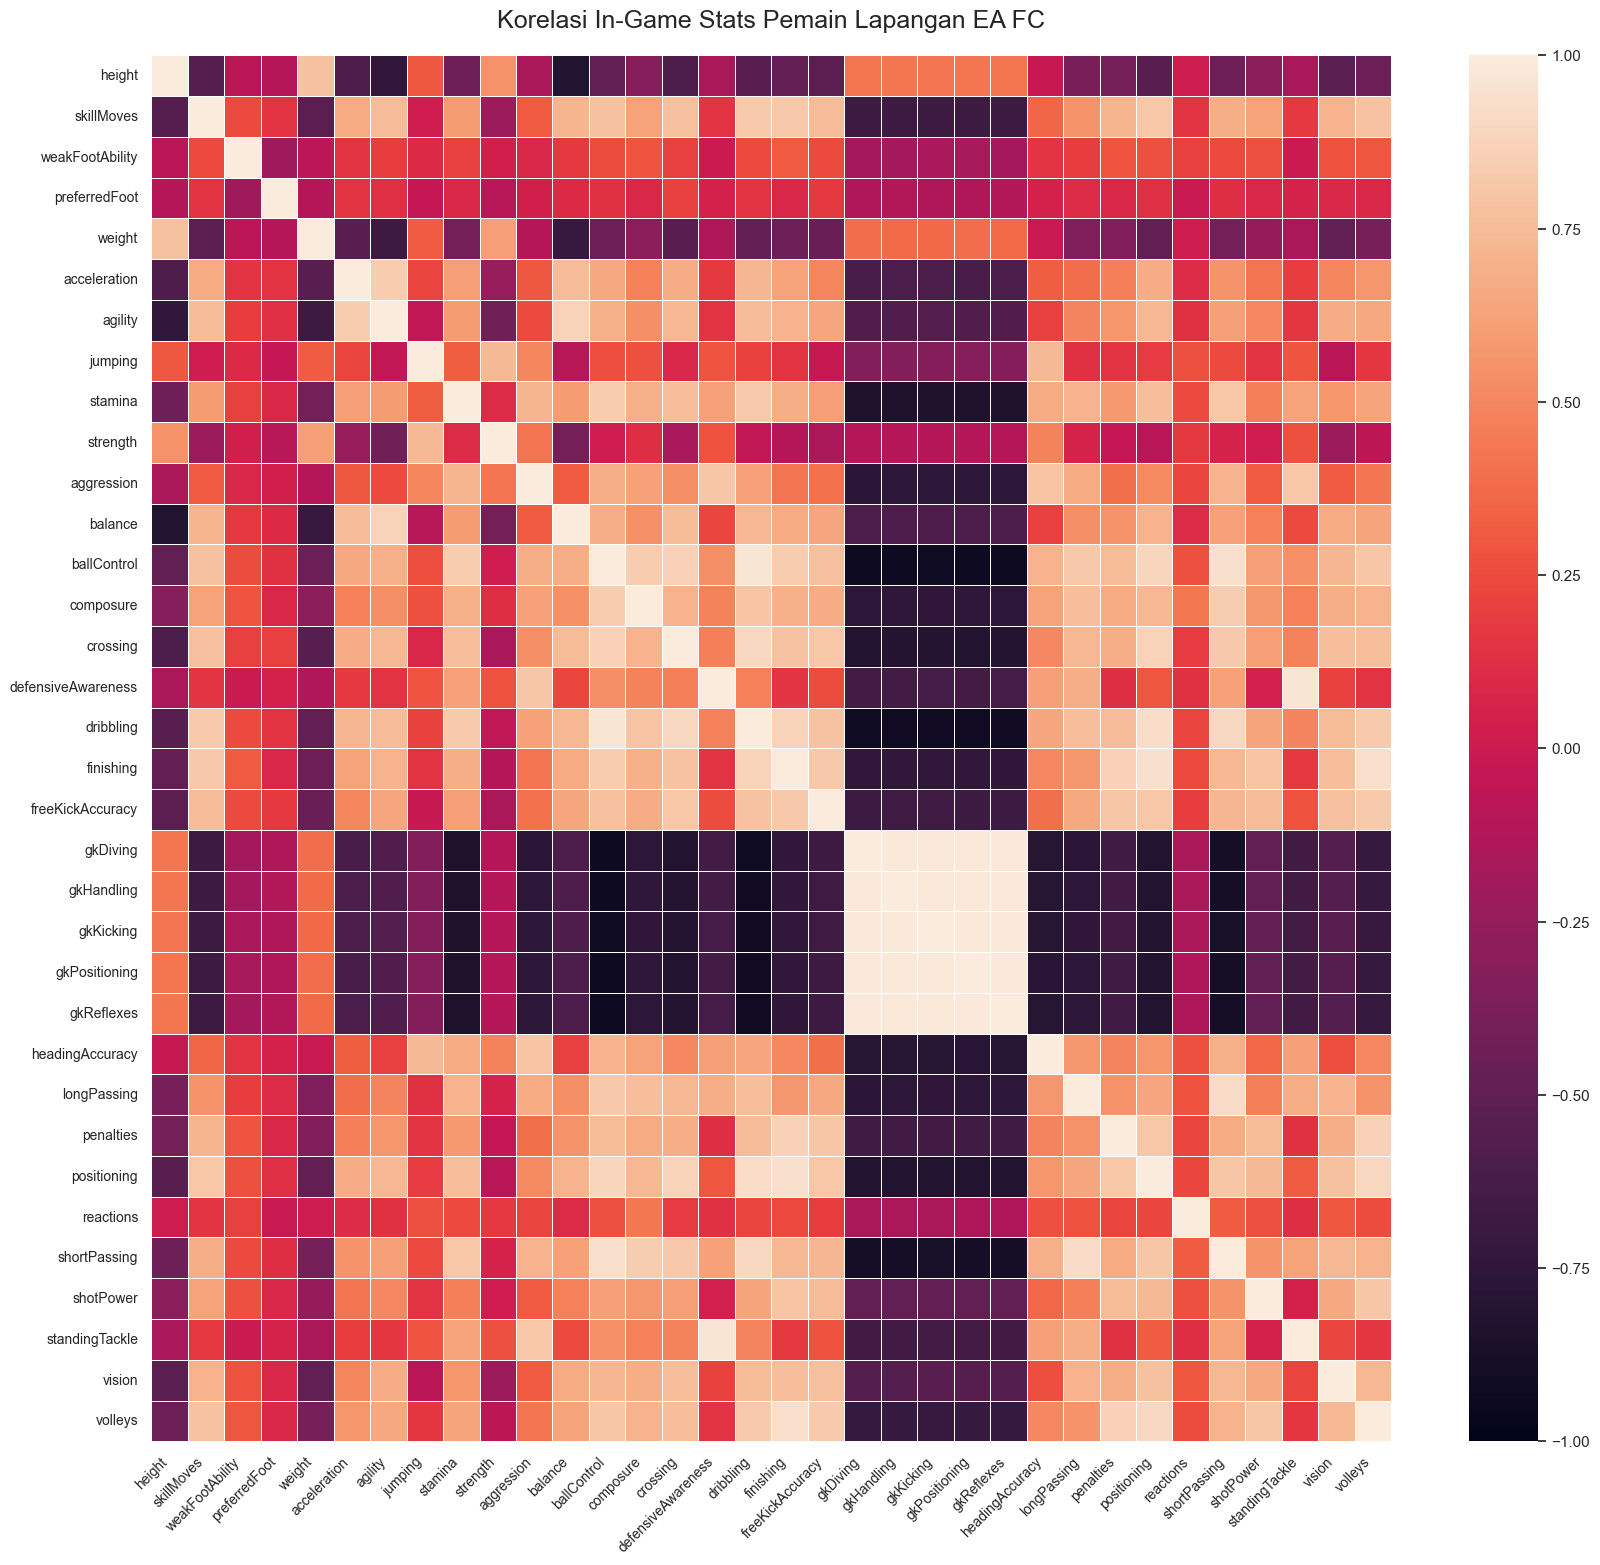

In [ ]:
plt.figure(figsize=(20, 18)) 

sns.heatmap(
    df_clean.corr(numeric_only=True), 
    vmin=-1, vmax=1,
    linewidths=0.5
)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.title("Korelasi In-Game Stats Pemain Lapangan EA FC", fontsize=18, pad=20)

plt.show()

In [31]:
fullname = df_clean["firstName"] + " " + df_clean["lastName"] + " '" + df_clean["commonName"].fillna('') + "'" 
fullname = fullname.str.replace(" ''", "").str.strip()

df_clean.insert(0, 'fullName', fullname)
df_clean = df_clean.drop(columns=['firstName', 'lastName', 'commonName'])
df_clean

,fullName,height,skillMoves,weakFootAbility,preferredFoot,leagueName,weight,alternatePositions_0_label,playerAbilities_0_label,playerAbilities_0_description,...,penalties,positioning,reactions,shortPassing,shotPower,standingTackle,vision,volleys,alternatePositions_1_label,alternatePositions_2_label
0,Mohamed Salah,175,4,3,2,Premier League,72,Right Wing,Low Driven Shot,Enhances a player's ability to execute low dri...,...,88,93,94,88,83,43,89,83,NaN,NaN
1,Kylian Mbappé,182,5,4,1,LALIGA EA SPORTS,75,Left Wing,Finesse Shot,Faster finesse shots with more curve and accuracy,...,82,91,91,87,91,34,83,87,Left Midfielder,NaN
2,Ousmane Dembélé,178,5,5,2,Ligue 1 McDonald's,67,Right Wing,Low Driven Shot,Enhances a player's ability to execute low dri...,...,80,95,91,89,91,49,84,79,Center Attacking Midfielder,NaN
3,Rodrigo Hernández Cascante 'Rodri',190,3,4,1,Premier League,82,Center Midfielder,Power Shot,Faster power shots with increased speed,...,62,76,93,93,92,87,84,71,NaN,NaN
4,Virgil van Dijk,193,2,3,1,Premier League,92,NaN,Precision Header,Performs headers with increased accuracy and p...,...,62,47,90,80,81,91,70,45,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Jose Luís García Vayá 'Pepelu',186,3,3,1,LALIGA EA SPORTS,73,Center Defensive Midfielder,Finesse Shot,Faster finesse shots with more curve and accuracy,...,83,69,73,80,73,78,76,65,NaN,NaN
996,Alexis Claude-Maurice,175,4,3,1,Bundesliga,62,Center Midfielder,Technical,"Faster Controlled Sprint, precise wide turns w...",...,65,74,73,77,76,71,76,58,Left Wing,NaN
997,Diego Manuel J. da Silva Moreira 'Diego Moreira',179,4,3,2,Ligue 1 McDonald's,73,Left Back,Gamechanger,Fancy and Trivela shots are performed with imp...,...,60,73,74,72,70,66,70,58,NaN,NaN
998,Alphonse Areola,195,1,3,1,Premier League,94,NaN,Far Throw,Unique goalkeeper throw animations with longer...,...,25,17,74,48,56,18,59,16,NaN,NaN


In [32]:
missing_data = df_clean.isna().sum()
print(missing_data[missing_data > 0])
print(len(df_clean))

alternatePositions_0_label       323
playerAbilities_0_label           51
playerAbilities_0_description     51
playerAbilities_0_type_label      51
playerAbilities_1_label          223
playerAbilities_1_description    223
playerAbilities_1_type_label     223
playerAbilities_2_label          421
playerAbilities_2_description    421
playerAbilities_2_type_label     421
playerAbilities_3_label          614
playerAbilities_3_description    614
playerAbilities_3_type_label     614
playerAbilities_4_label          775
playerAbilities_4_description    775
playerAbilities_4_type_label     775
playerAbilities_5_label          871
playerAbilities_5_description    871
playerAbilities_5_type_label     871
playerAbilities_6_label          943
playerAbilities_6_description    943
playerAbilities_6_type_label     943
team_name                         24
alternatePositions_1_label       671
alternatePositions_2_label       931
dtype: int64
1000


In [33]:
col_mean_nan = df_clean.columns[df_clean.isna().mean() > 0.7]
df_clean = df_clean.drop(columns=col_mean_nan)
list(df_clean.columns.values)

['fullName',
 'height',
 'skillMoves',
 'weakFootAbility',
 'preferredFoot',
 'leagueName',
 'weight',
 'alternatePositions_0_label',
 'playerAbilities_0_label',
 'playerAbilities_0_description',
 'playerAbilities_0_type_label',
 'playerAbilities_1_label',
 'playerAbilities_1_description',
 'playerAbilities_1_type_label',
 'playerAbilities_2_label',
 'playerAbilities_2_description',
 'playerAbilities_2_type_label',
 'playerAbilities_3_label',
 'playerAbilities_3_description',
 'playerAbilities_3_type_label',
 'nationality',
 'team_name',
 'position_name',
 'position_positionType_name',
 'acceleration',
 'agility',
 'jumping',
 'stamina',
 'strength',
 'aggression',
 'balance',
 'ballControl',
 'composure',
 'crossing',
 'defensiveAwareness',
 'dribbling',
 'finishing',
 'freeKickAccuracy',
 'gkDiving',
 'gkHandling',
 'gkKicking',
 'gkPositioning',
 'gkReflexes',
 'headingAccuracy',
 'longPassing',
 'penalties',
 'positioning',
 'reactions',
 'shortPassing',
 'shotPower',
 'standingTac

In [34]:
missing_data = df_clean.isna().sum()
print(missing_data[missing_data > 0])
print(len(df_clean))

alternatePositions_0_label       323
playerAbilities_0_label           51
playerAbilities_0_description     51
playerAbilities_0_type_label      51
playerAbilities_1_label          223
playerAbilities_1_description    223
playerAbilities_1_type_label     223
playerAbilities_2_label          421
playerAbilities_2_description    421
playerAbilities_2_type_label     421
playerAbilities_3_label          614
playerAbilities_3_description    614
playerAbilities_3_type_label     614
team_name                         24
alternatePositions_1_label       671
dtype: int64
1000


In [35]:
df_clean = df_clean.fillna("-")

In [36]:
df_clean.insert(0, 'id', [f"player{i}" for i in range(len(df_clean))])

In [37]:
# df_encoded.dtypes
df_num = df_clean.select_dtypes(int)
df_cat = df_clean.select_dtypes(object)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12596\2943091546.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_cat = df_clean.select_dtypes(object)


In [38]:
df_num.insert(0, 'id', df_cat['id'])
df_num.insert(1, 'fullName', df_cat['fullName'])

# df_cat.drop(columns=["team_name", "leagueName"])

In [39]:
# acc_mean = df_num["acceleration"].mean()
# acc_median = df_num["acceleration"].median()
# abs(acc_mean - acc_median) > 1

stand_scaler = StandardScaler()
rob_scaler = RobustScaler()

for i in df_num.iloc[:, 2:].columns:
    if abs(df_num[i].mean()-df_num[i].median()) > 1:
        df_num[i] = rob_scaler.fit_transform(df_num[[i]])
    else:
        df_num[i] = stand_scaler.fit_transform(df_num[[i]])


## **Training**  
---  

### Menggabungkan Fitur Kategorik
Langkah pertama adalah menggabungkan semua kolom kategorik menjadi satu string:
- **astype(str)**: Mengubah semua nilai kolom menjadi string (untuk menghindari error)
- **agg(' '.join, axis=1)**: Menggabungkan semua kolom per baris dengan spasi sebagai pemisah
- **Hasil**: Setiap pemain memiliki string "combined" yang berisi informasi kategorik seperti posisi, tim, kebangsaan, dll
- Contoh: "player0 Center Back Manchester United England" untuk pemain pertama

Kombinasi ini akan digunakan untuk menghitung similarity berdasarkan kesamaan atribut kategorik.

In [40]:
df_cat["combined"] = df_cat.astype(str).agg(' '.join, axis=1)

### Mengubah Teks menjadi Matrix Numerik (Bag of Words)
CountVectorizer mengubah teks menjadi matrix yang mewakili frekuensi kata-kata:
- **CountVectorizer()**: Membuat object untuk konversi teks ke matrix
- **fit_transform()**: 
  - Menghitung vocabulary (daftar kata unik) dari semua string "combined"
  - Mengubah setiap string menjadi vektor dengan menghitung frekuensi setiap kata
- **Hasil**: Matrix sparse dengan bentuk (jumlah_pemain, jumlah_kata_unik)
  - Setiap baris = satu pemain
  - Setiap kolom = satu kata (vocabulary item)
  - Nilai = frekuensi kata tersebut di combined string pemain

Contoh: Jika kata "Center" muncul di 100 pemain, kolom "Center" akan memiliki nilai frequency di setiap baris yang sesuai.

In [41]:
cv = CountVectorizer()
count_matrix = cv.fit_transform(df_cat['combined'])
print("Count Matrix: ",count_matrix.toarray())

Count Matrix:  [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


### Menghitung Cosine Similarity Berdasarkan Fitur Kategorik
Menghitung similarity antara semua pasangan pemain berdasarkan kesamaan atribut kategorik:
- **cosine_similarity()**: Fungsi dari sklearn yang menghitung similarity antara vektor-vektor
- **Cosine Similarity**: Mengukur sudut antara dua vektor (bukan jarak Euclidean)
  - Nilai 1 = vektor identik (dua pemain dengan atribut kategorik sangat mirip)
  - Nilai 0 = vektor ortogonal (tidak ada kesamaan atribut kategorik)
  - Nilai antara 0-1 = tingkat kesamaan parsial
- **Hasil**: Matrix (n_players × n_players)
  - cosine_sim_cat[i][j] = similarity score antara pemain i dan pemain j
  - Matrix simetris (cosine_sim_cat[i][j] = cosine_sim_cat[j][i])
  - Diagonal bernilai 1 (setiap pemain mirip 100% dengan dirinya sendiri)

In [42]:
cosine_sim_cat = cosine_similarity(count_matrix)

### Fungsi Pencarian Pemain berdasarkan Nama
Fungsi helper untuk menemukan index pemain berdasarkan nama yang diberikan:
- **str.contains(fullName, case=False, na=False)**: Mencari pemain yang nama-nya mengandung text yang dicari
  - **case=False**: Pencarian case-insensitive (Ronaldo = ronaldo = RONALDO)
  - **na=False**: Mengabaikan baris dengan nilai NaN/kosong
- **hasil_pencarian**: DataFrame berisi pemain yang cocok dengan pencarian
- **return index[0]**: Mengembalikan index (posisi) pemain pertama yang cocok
- **Jika tidak ditemukan**: Print pesan error dan return None

Contoh: get_id_from("Casemiro", df_cat) akan mengembalikan index pemain Casemiro di DataFrame

In [43]:
def get_id_from(fullName,df):
    hasil_pencarian = df[df['fullName'].str.contains(fullName, case=False, na=False)]
    if len(hasil_pencarian) > 0:
        return hasil_pencarian["id"].index[0]
    else:
        print(f"Pemain dengan nama '{fullName}' tidak ditemukan.")
        return None
    
idx_cat = get_id_from("Casemiro",df_cat)

In [44]:
similar_player_cat = list(enumerate(cosine_sim_cat[idx_cat]))

In [45]:
sorted_similar_player_cat = sorted(similar_player_cat, key = lambda x:x[1], reverse = True)

In [46]:
def get_player_from_id(index,df):
    return df[df.index == index]["fullName"].values[0]

i=0
for player in sorted_similar_player_cat:
    print(get_player_from_id(player[0],df_cat))
    i = i+1;
    if i == 1:
        print("-"*35)
        print("Opsi Pemain Pengganti yang Sesuai: ")
        print("-"*35)
    if i>20:
        break

Carlos Henrique Venancio Casimiro 'Casemiro'
-----------------------------------
Opsi Pemain Pengganti yang Sesuai: 
-----------------------------------
Amir Rrahmani
Dean Huijsen
Fábio Henrique Tavares 'Fabinho'
Idrissa Gueye
Jefferson Lerma
Beñat Prados Díaz 'Beñat Prados'
Mario Hermoso Canseco 'Mario Hermoso'
Sebastián Coates
Charles Vanhoutte
Anton Stach
Andrey N. dos Santos 'Andrey Santos'
Benjamin André
Francesco Acerbi
Amadou Onana
Aschraf El Mahdioui
Kalidou Koulibaly
James Tarkowski
Marten de Roon
Leandro Paredes
Jules Koundé


In [47]:
cosine_sim_num = cosine_similarity(df_num.iloc[:, 2:])

### Menghitung Cosine Similarity Berdasarkan Fitur Numerik
Menghitung similarity antara semua pasangan pemain berdasarkan kesamaan statistik in-game mereka:
- **df_num.iloc[:, 2:]**: Mengambil semua kolom numerik (mulai dari kolom ke-3) yang berisi in-game stats
  - Kolom 0-1 adalah 'id' dan 'fullName' (bukan stats)
  - Kolom 2+ adalah stats pemain (acceleration, pace, dribbling, shooting, dll) yang sudah dinormalisasi
- **cosine_similarity()**: Menghitung similarity antar pemain berdasarkan stats mereka
- **Hasil**: Matrix (n_players × n_players)
  - cosine_sim_num[i][j] = similarity score pemain i dan j berdasarkan in-game stats
  - Nilai tinggi = dua pemain memiliki stats yang sangat mirip (kemampuan serupa)
  - Ini melengkapi similarity kategorik dengan informasi performa atletik pemain

In [48]:
idx = get_id_from("Casemiro", df_num)
similar_player_by_num = list(enumerate(cosine_sim_num[idx]))

In [49]:
sorted_similar_player_by_num = sorted(similar_player_by_num, key = lambda x:x[1], reverse = True)

### Menampilkan Rekomendasi Pemain Berdasarkan Similarity Numerik
Loop untuk menampilkan 15 pemain teratas yang paling mirip dengan Casemiro berdasarkan in-game stats:
- **enumerate()**: Mengakses similarity score dari sorted_similar_player_by_num
- **get_player_from_id()**: Mengkonversi index kembali ke nama pemain
- **Pemisah output**: Garis pemisah untuk memisahkan pemain target dengan rekomendasi
- **Top-15**: Menampilkan 15 rekomendasi teratas (bisa disesuaikan dengan mengubah if i>15)
- **Hasil**: Daftar pemain dengan stats serupa dengan Casemiro, berguna untuk menemukan replacement yang secara atletik mirip

Perbedaan dengan hasil kategorik: hasil ini fokus pada kesamaan statistik performa, bukan hanya atribut (posisi, tim, dll)

In [50]:
i=0
for player in sorted_similar_player_by_num:
    print(get_player_from_id(player[0],df_num))
    i = i+1;
    if i == 1:
        print("-"*35)
        print("Opsi Pemain Pengganti yang Sesuai: ")
        print("-"*35)
    if i>15:
        break

Carlos Henrique Venancio Casimiro 'Casemiro'
-----------------------------------
Opsi Pemain Pengganti yang Sesuai: 
-----------------------------------
Harry Maguire
Eric Dier
Florian Lejeune
Joachim Andersen
Niklas Süle
Robert Andrich
Fabian Schär
Matthias Ginter
Danilo Luís Hélio Pereira 'Danilo Pereira'
Nemanja Gudelj
Borja Iglesias Quintás 'Borja Iglesias'
Chris Wood
Ali Al Musrati
Dante Bonfim Costa Santos 'Dante'
Sander Berge


### Menggabungkan Similarity Kategorik dan Numerik (Weighted Combination)
Menggabungkan dua jenis similarity dengan bobot tertentu untuk mendapatkan similarity score final:
- **w_cat = 0.2**: Bobot untuk fitur kategorik (20%)
  - Atribut seperti posisi, tim, kebangsaan memiliki pengaruh 20%
- **w_num = 0.8**: Bobot untuk fitur numerik (80%)
  - In-game stats (kecepatan, dribbling, shooting, dll) memiliki pengaruh 80%
- **cosin_sim_final = (cosine_sim_cat * 0.2) + (cosine_sim_num * 0.8)**:
  - Formula weighted average dari kedua similarity matrix
  - Hasil: Matrix similarity akhir yang mempertimbangkan kedua aspek

**Rasionale**: Untuk rekomendasi pemain scouting, kemampuan/stats lebih penting daripada atribut formal (posisi bisa dikembangkan, tapi stats adalah kemampuan inti)

Bobot ini bisa disesuaikan sesuai kebutuhan (misal: w_cat=0.3, w_num=0.7 untuk lebih mempertimbangkan posisi)

In [51]:
w_cat = 0.2
w_num = 0.8

cosin_sim_final = (cosine_sim_cat * w_cat) + (cosine_sim_num * w_num)

### Dictionary Tier Posisi (Position Flexibility)
Mendefinisikan posisi mana saja yang bisa dianggap sebagai pengganti untuk setiap posisi utama:
- **Struktur**: Dictionary dengan posisi utama sebagai key, dan list posisi relevan sebagai value
- **Logika tiering**: 
  - **GK (Goalkeeper)**: Hanya GK yang bisa menggantikan GK (peran spesifik)
  - **Defender**: Center Back bisa diganti dengan Left/Right Back (semua defender)
  - **Midfielder**: Posisi tengah fleksibel - CDM, CAM, CM bisa saling menggantikan
  - **Winger**: Bisa diganti dengan posisi lain di garis depan (ST, CF)
  - **Striker**: Posisi serang fleksibel - Striker, CF, Winger bisa saling menggantikan

**Keuntungan**: Sistem tidak hanya merekomendasikan pemain dengan posisi identik, tapi juga posisi yang secara fungsional mirip

**Contoh**: Jika mencari CB (Center Back), sistem juga akan merekomendasikan RB/LB karena kesamaan defensif, bukan hanya CB murni

In [52]:
POSITION_TIERS = {
    # Kiper
    "Goalkeeper": ["Goalkeeper"],

    # Bek
    "Center Back":      ["Center Back", "Right Back", "Left Back"],
    "Right Back":       ["Right Back", "Center Back", "Right Midfielder"],
    "Left Back":        ["Left Back", "Center Back", "Left Midfielder"],

    # Gelandang
    "Center Midfielder":       ["Center Midfielder", "Center Defensive Midfielder", "Center Attacking Midfielder"],
    "Center Defensive Midfielder":     ["Center Defensive Midfielder", "Center Midfielder"],
    "Center Attacking Midfielder":     ["Center Attacking Midfielder", "Center Midfielder", "Right Winger", "Left Winger"],
    "Right Midfielder":         ["Right Midfielder", "Right Winger", "Center Midfielder"],
    "Left Midfielder":          ["Left Midfielder", "Left Winger", "Center Midfielder"],

    # Penyerang
    "Striker":      ["Striker", "Center Forward", "Right Winger", "Left Winger"],
    "Center Forward": ["Center Forward", "Striker", "Center Attacking Midfielder"],
    "Right Winger": ["Right Winger", "Striker", "Right Midfielder", "Center Attacking Midfielder"],
    "Left Winger":  ["Left Winger", "Striker", "Left Midfielder", "Center Attacking Midfielder"],
}

In [54]:
df_clean["player_card"] = df_master["shieldUrl"]
df_clean

,id,fullName,height,skillMoves,weakFootAbility,preferredFoot,leagueName,weight,alternatePositions_0_label,playerAbilities_0_label,...,penalties,positioning,reactions,shortPassing,shotPower,standingTackle,vision,volleys,alternatePositions_1_label,player_card
0,player0,Mohamed Salah,175,4,3,2,Premier League,72,Right Wing,Low Driven Shot,...,88,93,94,88,83,43,89,83,-,https://ratings-images-prod.pulse.ea.com/FC25/...
1,player1,Kylian Mbappé,182,5,4,1,LALIGA EA SPORTS,75,Left Wing,Finesse Shot,...,82,91,91,87,91,34,83,87,Left Midfielder,https://ratings-images-prod.pulse.ea.com/FC25/...
2,player2,Ousmane Dembélé,178,5,5,2,Ligue 1 McDonald's,67,Right Wing,Low Driven Shot,...,80,95,91,89,91,49,84,79,Center Attacking Midfielder,https://ratings-images-prod.pulse.ea.com/FC25/...
3,player3,Rodrigo Hernández Cascante 'Rodri',190,3,4,1,Premier League,82,Center Midfielder,Power Shot,...,62,76,93,93,92,87,84,71,-,https://ratings-images-prod.pulse.ea.com/FC25/...
4,player4,Virgil van Dijk,193,2,3,1,Premier League,92,-,Precision Header,...,62,47,90,80,81,91,70,45,-,https://ratings-images-prod.pulse.ea.com/FC25/...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,player995,Jose Luís García Vayá 'Pepelu',186,3,3,1,LALIGA EA SPORTS,73,Center Defensive Midfielder,Finesse Shot,...,83,69,73,80,73,78,76,65,-,https://ratings-images-prod.pulse.ea.com/FC25/...
996,player996,Alexis Claude-Maurice,175,4,3,1,Bundesliga,62,Center Midfielder,Technical,...,65,74,73,77,76,71,76,58,Left Wing,https://ratings-images-prod.pulse.ea.com/FC25/...
997,player997,Diego Manuel J. da Silva Moreira 'Diego Moreira',179,4,3,2,Ligue 1 McDonald's,73,Left Back,Gamechanger,...,60,73,74,72,70,66,70,58,-,https://ratings-images-prod.pulse.ea.com/FC25/...
998,player998,Alphonse Areola,195,1,3,1,Premier League,94,-,Far Throw,...,25,17,74,48,56,18,59,16,-,https://ratings-images-prod.pulse.ea.com/FC25/...


In [55]:
df_clean.columns.values

<ArrowStringArray>
[                           'id',                      'fullName',
                        'height',                    'skillMoves',
               'weakFootAbility',                 'preferredFoot',
                    'leagueName',                        'weight',
    'alternatePositions_0_label',       'playerAbilities_0_label',
 'playerAbilities_0_description',  'playerAbilities_0_type_label',
       'playerAbilities_1_label', 'playerAbilities_1_description',
  'playerAbilities_1_type_label',       'playerAbilities_2_label',
 'playerAbilities_2_description',  'playerAbilities_2_type_label',
       'playerAbilities_3_label', 'playerAbilities_3_description',
  'playerAbilities_3_type_label',                   'nationality',
                     'team_name',                 'position_name',
    'position_positionType_name',                  'acceleration',
                       'agility',                       'jumping',
                       'stamina',          

### Fungsi Rekomendasi Utama (Hybrid Approach dengan Position Tiering)
Fungsi komprehensif untuk merekomendasikan pemain pengganti dengan mempertimbangkan similarity dan posisi:

**Parameter:**
- **name**: Nama pemain yang ingin dicari penggantinya
- **top_n**: Jumlah rekomendasi yang diinginkan (default: 10)

**Logika 3-Tier:**
1. **Tier 1 (Prioritas Tertinggi)**: Pemain dengan posisi identik
   - Contoh: Jika mencari CB, prioritas utama adalah CB lain
2. **Tier 2 (Prioritas Menengah)**: Pemain dengan posisi relevan (dari POSITION_TIERS)
   - Contoh: Jika CB tidak cukup, gunakan RB/LB (defender lain)
3. **Tier 3 (Fallback)**: Semua pemain lain
   - Jika posisi relevan kurang, ambil dari posisi manapun berdasarkan similarity

**Output**: DataFrame dengan kolom:
- **fullName**: Nama pemain
- **position_name**: Posisi pemain
- **team_name**: Klub pemain
- **player_card**: Link ke kartu pemain

**Contoh**: get_recommendations("Dalot", 10) akan merekomendasikan 10 pemain terbaik untuk menggantikan Dalot (Left Back)

In [56]:
with open('aiscout_data.pkl', 'wb') as file:
    pickle.dump((df_clean, cosin_sim_final), file)

In [57]:
def get_recommendations(name, top_n=10):
    hits = df_clean[df_clean["fullName"].str.contains(name, case=False, na=False)]
    if hits.empty:
        return None

    idx      = hits.index[0]
    ref_pos  = hits.iloc[0].get("position_name", "")

    all_scores = list(enumerate(cosin_sim_final[idx]))
    all_scores = [(i, s) for i, s in all_scores if i != idx]
    all_scores = sorted(all_scores, key=lambda x: x[1], reverse=True)

    relevant_positions = POSITION_TIERS.get(ref_pos, [ref_pos])
    same_position      = [ref_pos]  # tier 1: sama persis

    result_indices = []

    tier1 = [
        i for i, s in all_scores
        if df_clean.loc[i, "position_name"] in same_position
    ][:top_n]
    result_indices.extend(tier1)

    if len(result_indices) < top_n:
        sisa = top_n - len(result_indices)
        tier2 = [
            i for i, s in all_scores
            if df_clean.loc[i, "position_name"] in relevant_positions
            and i not in result_indices
        ][:sisa]
        result_indices.extend(tier2)

    if len(result_indices) < top_n:
        sisa = top_n - len(result_indices)
        tier3 = [
            i for i, s in all_scores
            if i not in result_indices
        ][:sisa]
        result_indices.extend(tier3)

    cols = ["fullName", "position_name", "team_name", "player_card"]
    cols = [c for c in cols if c in df_clean.columns]
    return df_clean[cols].iloc[result_indices].reset_index(drop=True)

get_recommendations("Dalot", 200)

,fullName,position_name,team_name,player_card
0,Alexander Bah,Right Back,SL Benfica,https://ratings-images-prod.pulse.ea.com/FC25/...
1,Ola Aina,Right Back,Nott'm Forest,https://ratings-images-prod.pulse.ea.com/FC25/...
2,Anthony Caci,Right Back,1. FSV Mainz 05,https://ratings-images-prod.pulse.ea.com/FC25/...
3,Giovanni Di Lorenzo,Right Back,SSC Napoli,https://ratings-images-prod.pulse.ea.com/FC25/...
4,Gonzalo Montiel,Right Back,River Plate,https://ratings-images-prod.pulse.ea.com/FC25/...
...,...,...,...,...
195,Ezri Konsa,Center Back,Aston Villa,https://ratings-images-prod.pulse.ea.com/FC25/...
196,Florian Lejeune,Center Back,Rayo Vallecano,https://ratings-images-prod.pulse.ea.com/FC25/...
197,Benjamin Pavard,Center Back,OM,https://ratings-images-prod.pulse.ea.com/FC25/...
198,Ansgar Knauff,Right Midfielder,Frankfurt,https://ratings-images-prod.pulse.ea.com/FC25/...


## **Evaluasi**  
---  

### 1. Overview Dataset Evaluasi
Langkah pertama adalah melihat gambaran umum dataset yang akan digunakan untuk evaluasi:
- **Total pemain**: Jumlah keseluruhan pemain dalam dataset
- **Jumlah posisi unik**: Berapa banyak posisi berbeda yang tersedia
- **Distribusi pemain per posisi**: Melihat keseimbangan data di setiap posisi

Informasi ini penting untuk memahami cakupan evaluasi dan memastikan sistem bekerja dengan baik untuk semua posisi.

In [62]:
print("=== Evaluasi Sistem Rekomendasi AI Player Scouting ===")
print(f"Total pemain dalam dataset: {len(df_clean)}")
print(f"Posisi yang tersedia: {df_clean['position_name'].nunique()}")
print(df_clean['position_name'].value_counts())

=== Evaluasi Sistem Rekomendasi AI Player Scouting ===
Total pemain dalam dataset: 1000
Posisi yang tersedia: 12
position_name
Center Back                    162
Center Midfielder              117
Striker                        114
Goalkeeper                     112
Center Defensive Midfielder    111
Center Attacking Midfielder     87
Left Back                       67
Right Back                      64
Right Midfielder                57
Left Midfielder                 52
Right Wing                      30
Left Wing                       27
Name: count, dtype: int64


### 2. Fungsi Relevansi Posisi
Fungsi ini mengecek apakah posisi kandidat pemain cocok dengan posisi pemain referensi:
- **Tier matching**: Menggunakan `POSITION_TIERS` untuk menentukan posisi mana yang relevan
- **Return**: `True` jika posisi kandidat termasuk dalam tier posisi referensi, `False` sebaliknya

Misalnya: jika pemain referensi adalah "Striker", maka "Center Forward", "Right Winger", dan "Left Winger" dianggap relevan.

In [66]:
def is_relevant(ref_position, candidate_position):
    relevant_positions = POSITION_TIERS.get(ref_position, [ref_position])
    return candidate_position in relevant_positions

### 3. Fungsi Evaluasi Pemain Tunggal
Fungsi ini menghitung metrik kualitas rekomendasi untuk satu pemain:

**Metrik yang dihitung:**
- **Precision@N**: Proporsi rekomendasi yang memiliki posisi relevan (nilai 0-1)
  - Formula: (Jumlah rekomendasi dengan posisi relevan) / N
- **Avg Similarity**: Rata-rata skor cosine similarity dari top-N rekomendasi
  - Mengukur seberapa mirip pemain yang direkomendasikan dengan pemain referensi
- **Diversity**: Seberapa berbeda-beda pemain dalam rekomendasi
  - 1 - (rata-rata similarity antar rekomendasi)
  - Nilai tinggi = rekomendasi lebih beragam

**Contoh**: Jika mencari "Casemiro" dengan top_n=10, fungsi akan mengembalikan ketiga metrik tersebut.

In [67]:
import numpy as np

def evaluate_one_player(player_name, top_n=10):
    hits = df_clean[df_clean["fullName"].str.contains(player_name, case=False, na=False)]
    if hits.empty:
        return None

    idx     = hits.index[0]
    ref_pos = df_clean.loc[idx, "position_name"]

    all_scores  = [(i, cosin_sim_final[idx][i]) for i in range(len(df_clean)) if i != idx]
    all_scores  = sorted(all_scores, key=lambda x: x[1], reverse=True)[:top_n]

    sim_scores  = [s for _, s in all_scores]
    rec_indices = [i for i, _ in all_scores]

    relevances = [
        is_relevant(ref_pos, df_clean.loc[i, "position_name"])
        for i in rec_indices
    ]

    precision_at_n = sum(relevances) / top_n
    avg_sim        = np.mean(sim_scores)

    rec_vectors = cosin_sim_final[np.ix_(rec_indices, rec_indices)]
    np.fill_diagonal(rec_vectors, 0)
    intra_sim = rec_vectors.sum() / (top_n * (top_n - 1)) if top_n > 1 else 0

    return {
        "player":         df_clean.loc[idx, "fullName"],
        "position":       ref_pos,
        "precision@N":    round(precision_at_n, 4),
        "avg_similarity": round(avg_sim, 4),
        "diversity":      round(1 - intra_sim, 4),
    }

# Test
result = evaluate_one_player("Casemiro", top_n=10)
print(result)

{'player': "Carlos Henrique Venancio Casimiro 'Casemiro'", 'position': 'Center Defensive Midfielder', 'precision@N': 0.1, 'avg_similarity': np.float64(0.6702), 'diversity': np.float64(0.3468)}


### 4. Evaluasi Sampel 100 Pemain
Langkah ini menjalankan evaluasi pada sampel 100 pemain acak untuk mendapatkan metrik keseluruhan:

**Proses:**
1. **Random Seed**: Menetapkan seed untuk reprodusibilitas hasil
2. **Sampling**: Mengambil 100 pemain acak dari dataset
3. **Looping**: Untuk setiap pemain, hitung precision@10, avg_similarity, dan diversity
4. **DataFrame**: Kumpulkan semua hasil ke dalam DataFrame untuk analisis statistik

**Keuntungan**: Dengan mengevaluasi banyak pemain, kita bisa melihat:
- Rata-rata dan distribusi performa sistem
- Keandalan sistem across berbagai pemain
- Posisi mana yang performanya baik/buruk

In [68]:
np.random.seed(42)
sample_players = df_clean["fullName"].dropna().sample(100).tolist()

eval_results = []
for name in sample_players:
    res = evaluate_one_player(name, top_n=10)
    if res:
        eval_results.append(res)

df_eval = pd.DataFrame(eval_results)
print("=== HASIL EVALUASI (100 pemain sampel) ===")
print(df_eval.describe())

=== HASIL EVALUASI (100 pemain sampel) ===
       precision@N  avg_similarity   diversity
count   100.000000      100.000000  100.000000
mean      0.669000        0.708995    0.349941
std       0.330196        0.107937    0.133077
min       0.000000        0.487700    0.050000
25%       0.400000        0.633125    0.289925
50%       0.800000        0.704900    0.356150
75%       1.000000        0.761500    0.440225
max       1.000000        0.958400    0.612900


### 5. Visualisasi Distribusi Metrik Evaluasi
Membuat tiga histogram untuk melihat distribusi ketiga metrik utama:

**Subplot 1 - Precision@10:**
- Menunjukkan berapa banyak pemain dengan precision tertentu
- Nilai tinggi (dekat 1) = banyak rekomendasi relevan dengan posisi pemain
- Histogram ini membantu melihat konsistensi sistem dalam memberikan rekomendasi yang relevan

**Subplot 2 - Average Cosine Similarity:**
- Distribusi kemiripan rata-rata pemain yang direkomendasikan
- Nilai tinggi = rekomendasi sangat mirip dengan pemain referensi
- Membantu menilai apakah sistem menemukan pemain dengan kemampuan serupa

**Subplot 3 - Diversity Score:**
- Distribusi keberagaman rekomendasi
- Nilai tinggi = rekomendasi lebih variatif/beragam
- Penting untuk memastikan sistem tidak hanya merekomendasikan "clone" pemain yang sama

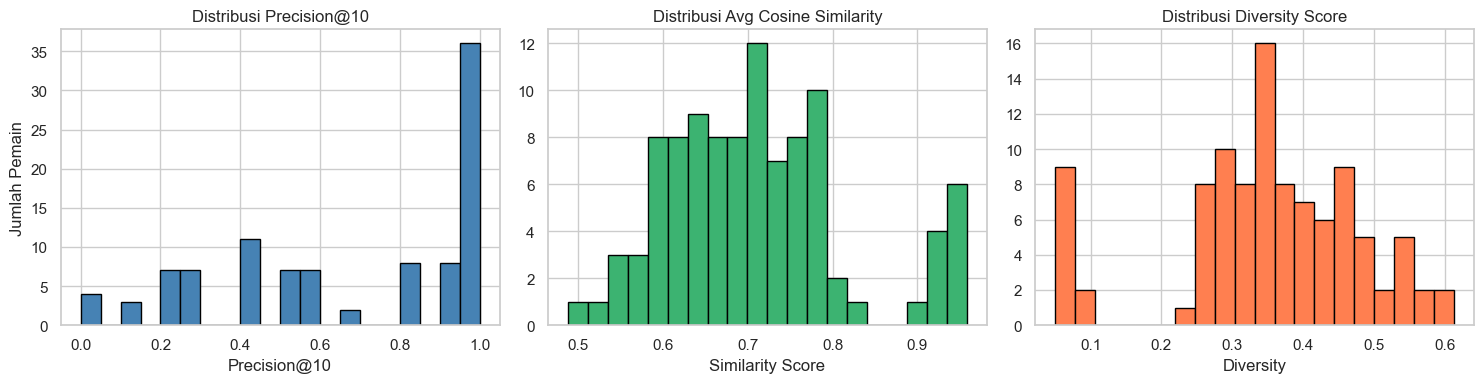

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# precission at k = 10
df_eval["precision@N"].hist(ax=axes[0], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title("Distribusi Precision@10")
axes[0].set_xlabel("Precision@10")
axes[0].set_ylabel("Jumlah Pemain")

# cosine avg similartity
df_eval["avg_similarity"].hist(ax=axes[1], bins=20, color='mediumseagreen', edgecolor='black')
axes[1].set_title("Distribusi Avg Cosine Similarity")
axes[1].set_xlabel("Similarity Score")

# diversity
df_eval["diversity"].hist(ax=axes[2], bins=20, color='coral', edgecolor='black')
axes[2].set_title("Distribusi Diversity Score")
axes[2].set_xlabel("Diversity")

plt.tight_layout()
plt.show()

### 6. Analisis Precision per Posisi
Visualisasi performa sistem rekomendasi untuk setiap posisi:

**Cara membaca chart:**
- **X-axis (Posisi)**: Berbagai posisi pemain (GK, CB, LB, RB, CM, CAM, ST, dll)
- **Y-axis (Precision@10)**: Rata-rata precision untuk setiap posisi (0-1)
- **Bar yang lebih tinggi** = sistem lebih akurat merekomendasikan pemain dengan posisi relevan

**Insight yang bisa didapat:**
- Posisi mana yang sistem kuasai dengan baik (precision tinggi)
- Posisi mana yang masih butuh improvement (precision rendah)
- Apakah ada bias terhadap posisi tertentu
- Contoh: Jika posisi Striker memiliki precision 0.9, berarti 9 dari 10 rekomendasi adalah posisi relevan untuk striker

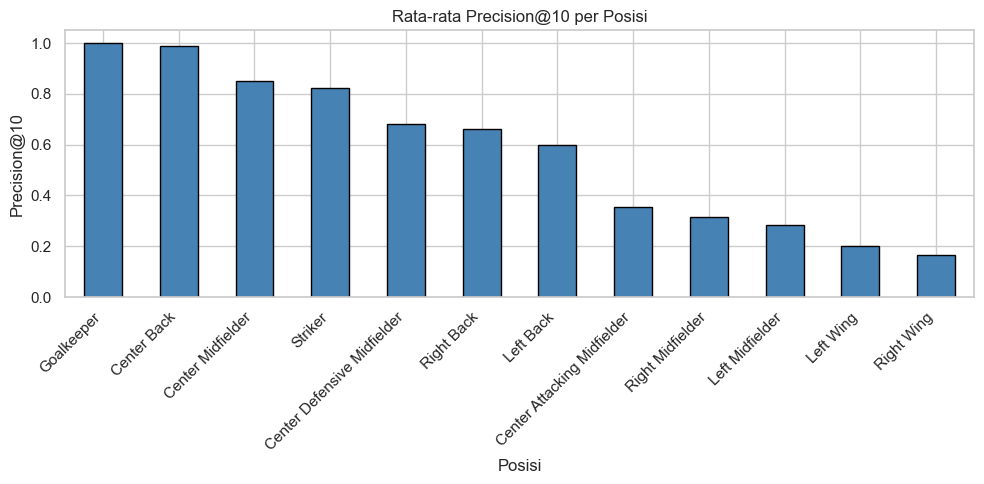

In [70]:
# Precision per posisi
precision_by_pos = df_eval.groupby("position")["precision@N"].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
precision_by_pos.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Rata-rata Precision@10 per Posisi")
plt.ylabel("Precision@10")
plt.xlabel("Posisi")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()